# Environement

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'


import numpy as np

from eci.environment import EnvConfig, Environment

# Local project imports
from eci.plots import plot_belief_trajectory
from eci.utils import get_voter_trajectory_data

# How observation work?

When you specify a scenario, the function generate observations return a numpy.ndarray (a multi-dimensional array) containing floating-point numbers.

The shape of the array is: $(n\_steps, n\preference)$Axis 0 (Rows): Represents time ($n\_steps$).Axis 1 (Columns): Represents each specific preference ($n\_nodes$).

Values are strictly between $0.0$ and $1.0$ (clipped at the end of the function). Logic: The data represents synthetic observations (probabilities or rates) following a Beta distribution, potentially affected by shocks or trends and Gaussian noise.

Visual RepresentationIf you call generate_observations(n_nodes=3, n_steps=5), the resulting matrix looks like this:$$\begin{bmatrix}
t_0n_0 & t_0n_1 & t_0n_2 \\
t_1n_0 & t_1n_1 & t_1n_2 \\
t_2n_0 & t_2n_1 & t_2n_2 \\
t_3n_0 & t_3n_1 & t_3n_2 \\
t_4n_0 & t_4n_1 & t_4n_2
\end{bmatrix}$$

In [16]:
config = EnvConfig(
    num_voters=50, num_candidates=4, num_preferences=2, scenario=2, num_steps=100
)
NUM_SIMULATIONS = 100

In [17]:
# Initialize environment
env = Environment(config)
env.num_simulations = NUM_SIMULATIONS
env._run_multi_agent_inference()

In [ ]:
env.input_data  # (100 timestep,2 preference)

array([[0.91450657, 0.87819158],
       [1.        , 0.97866706],
       [1.        , 0.98241467],
       [0.96830391, 1.        ],
       [1.        , 0.945551  ],
       [0.89584257, 0.82826893],
       [0.95064778, 1.        ],
       [0.92782453, 0.95134339],
       [1.        , 0.75583387],
       [0.7786805 , 0.84620808],
       [0.99284935, 0.99229587],
       [0.90203175, 1.        ],
       [0.94315063, 0.97140145],
       [1.        , 1.        ],
       [0.73900399, 0.91278183],
       [0.95827896, 1.        ],
       [0.92470442, 0.95589826],
       [0.92319522, 0.69856884],
       [0.97973395, 0.9464425 ],
       [1.        , 0.9459149 ],
       [0.92645456, 0.79882979],
       [0.91178506, 1.        ],
       [0.70325814, 1.        ],
       [0.94978098, 0.7586862 ],
       [1.        , 1.        ],
       [0.97422767, 0.99529666],
       [0.96725853, 0.95212424],
       [0.91486012, 1.        ],
       [1.        , 0.93601993],
       [0.95482227, 0.91104529],
       [0.

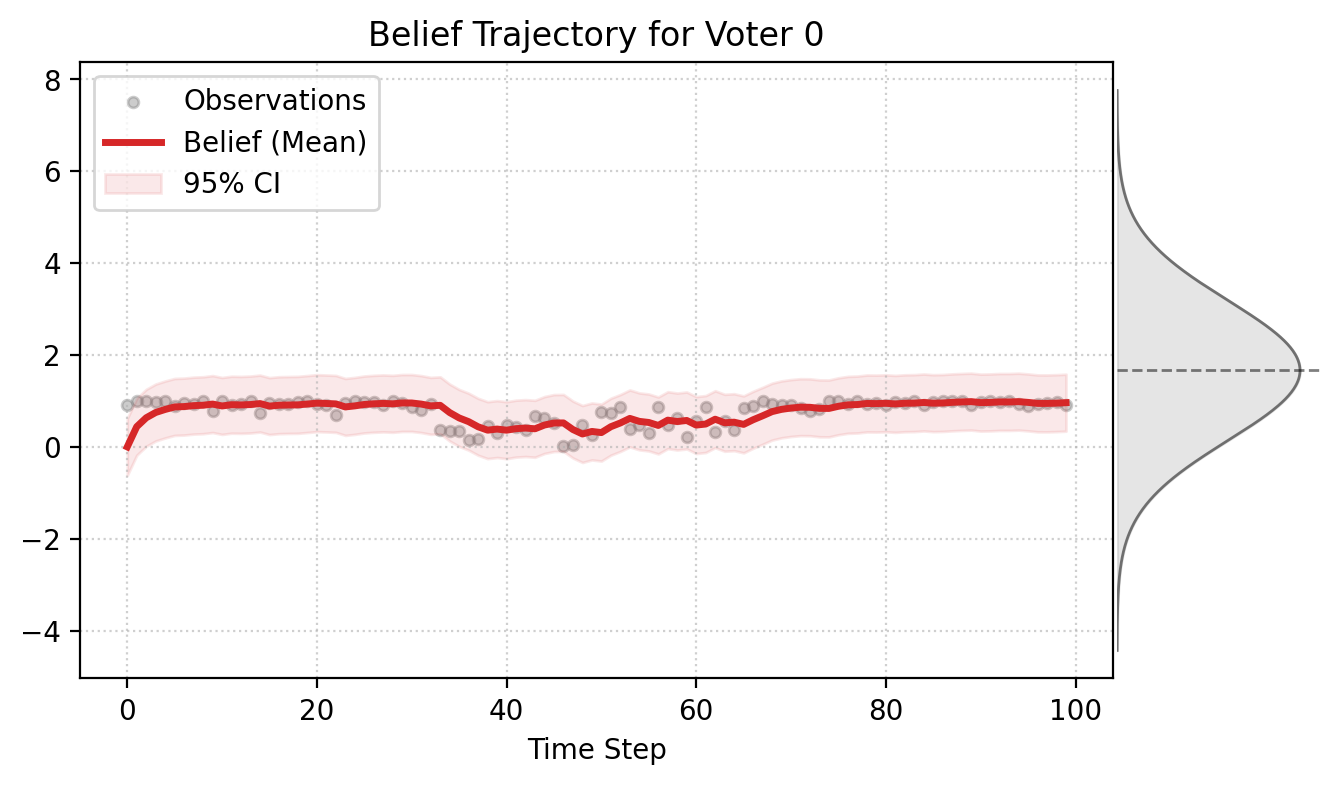

In [20]:
traj_data = get_voter_trajectory_data(env, voter_id=0)
fig, ax1, ax2 = plot_belief_trajectory(**traj_data)

# How to create observations manually?

To replicate the data structure expected by your pipeline without using the generator, you can use NumPy. Here are three ways to do it:

In [24]:
# Example: 3 time steps, 2 nodes
manual_obs = np.array(
    [
        [0.10, 0.95],  # Time t=0: Node 0 is low, Node 1 is high
        [3.20, 0.90],  # Time t=1
        [0.50, 0.50],  # Time t=2: Both converge
    ]
)

print(f"Shape: {manual_obs.shape}")
# Output: (3, 2) -> (n_steps, n_nodes)

Shape: (3, 2)


In [25]:
# Initialize environment
env = Environment(config)
env.input_data = manual_obs
env.num_simulations = NUM_SIMULATIONS
env._run_multi_agent_inference()

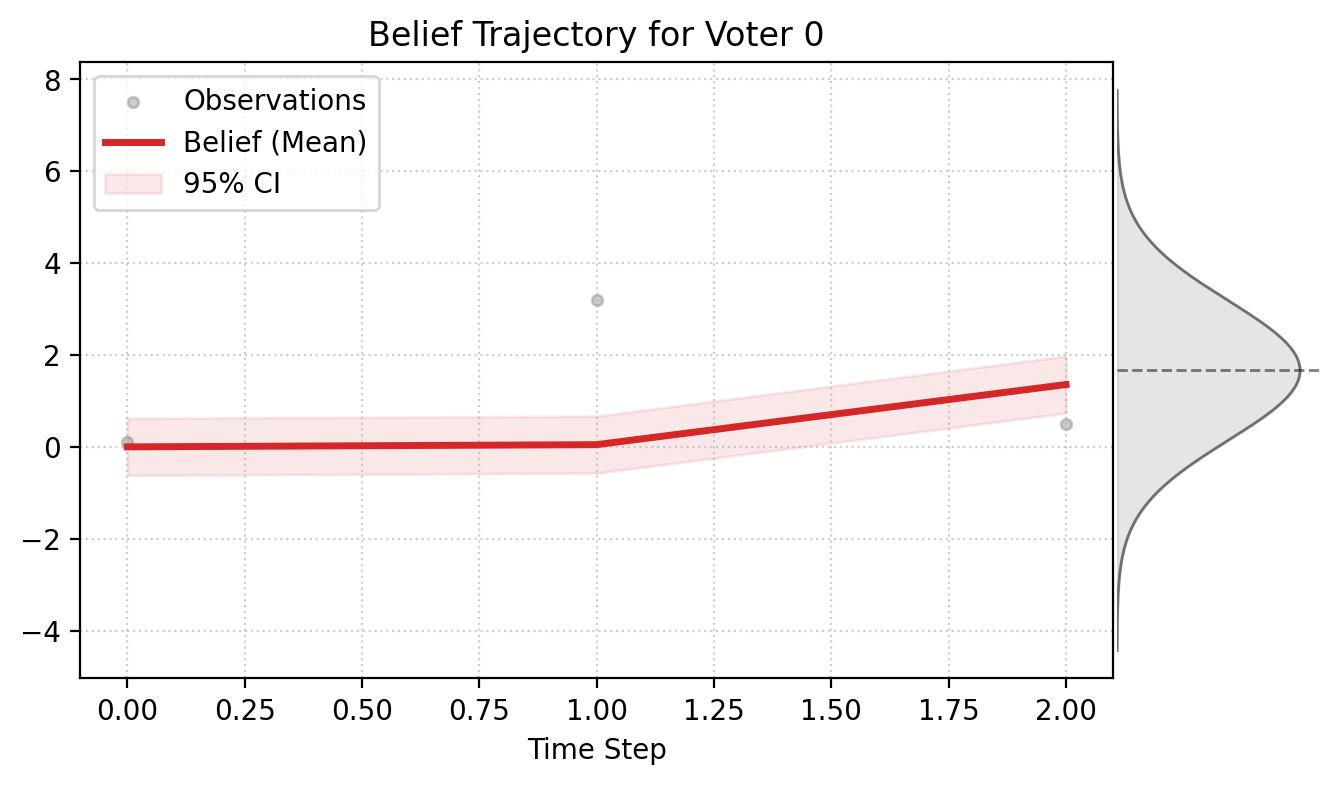

In [26]:
traj_data = get_voter_trajectory_data(env, voter_id=0)
fig, ax1, ax2 = plot_belief_trajectory(**traj_data)

# Volatility

In [ ]:
env.agents[0].tonic_volatility

2

env.